# NYC Taxi Trips — Big Data Analytics with PySpark

**Business Question:** What drives demand and revenue for NYC yellow taxis, and what
can the data (and its quality) tell us to support fleet, pricing, and staffing decisions?

**Dataset:** NYC Yellow Taxi Trip Records — **~9.5M trips** (2024, Q1) + taxi zone lookup
**Tools:** PySpark (Spark SQL + DataFrame API) · Docker · matplotlib

---

**Workflow:**
1. Load ~9.5M rows from Parquet with Spark
2. Data-quality checks + NULL investigation
3. Cleaning (business rules)
4. Insight 1 — Hourly demand
5. Insight 2 — Weekly demand pattern
6. Insight 3 — Revenue by pickup zone
7. Insight 4 — Payment methods & the tipping data trap
8. Conclusions

In [1]:
from pyspark.sql import SparkSession

# Create the SparkSession — our entry point to Spark
spark = (
    SparkSession.builder
    .appName("NYC Taxi Analytics")
    .master("local[4]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

# Reduce log noise so output stays clean
spark.sparkContext.setLogLevel("WARN")

print("Spark version:", spark.version)
spark

Spark version: 3.5.0


In [2]:
# Read all 3 monthly Parquet files at once using a wildcard
df = spark.read.parquet("data/raw/yellow_tripdata_2024-*.parquet")

# How many trips did we load?
print(f"Total trips: {df.count():,}")
print(f"Columns: {len(df.columns)}")


Total trips: 9,554,778
Columns: 19


In [3]:
# Show the structure of the data: column names and types
df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



In [4]:
# Show the first 5 rows for the most relevant columns
df.select(
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "trip_distance", "PULocationID", "DOLocationID",
    "fare_amount", "total_amount"
).show(5, truncate=False)

+--------------------+---------------------+-------------+------------+------------+-----------+------------+
|tpep_pickup_datetime|tpep_dropoff_datetime|trip_distance|PULocationID|DOLocationID|fare_amount|total_amount|
+--------------------+---------------------+-------------+------------+------------+-----------+------------+
|2024-01-01 00:57:55 |2024-01-01 01:17:43  |1.72         |186         |79          |17.7       |22.7        |
|2024-01-01 00:03:00 |2024-01-01 00:09:36  |1.8          |140         |236         |10.0       |18.75       |
|2024-01-01 00:17:06 |2024-01-01 00:35:01  |4.7          |236         |79          |23.3       |31.3        |
|2024-01-01 00:36:38 |2024-01-01 00:44:56  |1.4          |79          |211         |10.0       |17.0        |
|2024-01-01 00:46:51 |2024-01-01 00:52:57  |0.8          |211         |148         |7.9        |16.1        |
+--------------------+---------------------+-------------+------------+------------+-----------+------------+
only showi

In [5]:
from pyspark.sql import functions as F

# Compute several data-quality checks in a single pass over the data
df.select(
    F.count("*").alias("total_rows"),
    F.sum(F.when(F.col("trip_distance") <= 0, 1).otherwise(0)).alias("zero_distance"),
    F.sum(F.when(F.col("fare_amount") <= 0, 1).otherwise(0)).alias("zero_or_neg_fare"),
    F.sum(F.when(F.col("passenger_count") == 0, 1).otherwise(0)).alias("zero_passengers"),
    F.sum(F.when(F.col("trip_distance") > 100, 1).otherwise(0)).alias("distance_over_100mi"),
    F.sum(F.when(F.col("fare_amount") > 500, 1).otherwise(0)).alias("fare_over_500"),
).show()


+----------+-------------+----------------+---------------+-------------------+-------------+
|total_rows|zero_distance|zero_or_neg_fare|zero_passengers|distance_over_100mi|fare_over_500|
+----------+-------------+----------------+---------------+-------------------+-------------+
|   9554778|       215764|          139596|         105931|                252|          117|
+----------+-------------+----------------+---------------+-------------------+-------------+



In [6]:
# Apply business rules to keep only valid trips
df_clean = df.filter(
    (F.col("trip_distance") > 0) & (F.col("trip_distance") <= 100) &
    (F.col("fare_amount") > 0) & (F.col("fare_amount") <= 500) &
    (F.col("passenger_count") > 0)
)

rows_before = df.count()
rows_after = df_clean.count()
removed = rows_before - rows_after

print(f"Rows before : {rows_before:,}")
print(f"Rows after  : {rows_after:,}")
print(f"Removed     : {removed:,} ({removed/rows_before*100:.2f}%)")


Rows before : 9,554,778
Rows after  : 8,479,483
Removed     : 1,075,295 (11.25%)


### Data Quality: Investigating the NULL Discovery

Applying the cleaning filters removed **11.25%** of the rows — but the individual
problems measured earlier only summed to about **4.8%**. That gap is worth
investigating rather than ignoring.

**Root cause: NULL values.** The earlier check counted `passenger_count == 0`, but
not the **NULLs** (empty values). In Spark (and SQL in general), any comparison with
NULL returns **NULL**, not `True` or `False`:

- When filtering `passenger_count > 0`, a `NULL` value evaluates to `NULL > 0 = NULL`
- Since `filter` only keeps rows that evaluate to `True`, those NULL rows are **dropped**

The filter was therefore removing NULL rows too — ones the earlier measurement
never captured. The check below confirms this by counting NULLs directly in the key
columns.


In [7]:
# Count NULL values in the key columns
df.select(
    F.sum(F.col("passenger_count").isNull().cast("int")).alias("null_passenger"),
    F.sum(F.col("trip_distance").isNull().cast("int")).alias("null_distance"),
    F.sum(F.col("fare_amount").isNull().cast("int")).alias("null_fare"),
).show()


+--------------+-------------+---------+
|null_passenger|null_distance|null_fare|
+--------------+-------------+---------+
|        751962|            0|        0|
+--------------+-------------+---------+



**Confirmed:** `passenger_count` contains **751,962 NULL values**, while
`trip_distance` and `fare_amount` have none. Combined with the `== 0` cases and
the distance/fare outliers, this accounts for the full 11.25% removed by the
cleaning filter. Dropping these rows is appropriate here — a trip with no
recorded passenger count is not usable for modeling — but the decision is now
made knowingly rather than by accident.


In [8]:
# Cache the clean data in memory since it will be reused many times
df_clean.cache()

# Trigger the cache with a count (first action materializes it)
print(f"Clean trips cached: {df_clean.count():,}")


Clean trips cached: 8,479,483


In [9]:
# Register the clean DataFrame as a SQL temp view so we can query it with SQL
df_clean.createOrReplaceTempView("trips")

# Count trips per hour of the day
hourly = spark.sql("""
    SELECT HOUR(tpep_pickup_datetime) AS hour_of_day,
           COUNT(*) AS num_trips
    FROM trips
    GROUP BY HOUR(tpep_pickup_datetime)
    ORDER BY hour_of_day
""")

hourly.show(24)

+-----------+---------+
|hour_of_day|num_trips|
+-----------+---------+
|          0|   222292|
|          1|   148354|
|          2|    98574|
|          3|    66027|
|          4|    40672|
|          5|    46205|
|          6|   109122|
|          7|   227725|
|          8|   322534|
|          9|   369101|
|         10|   399095|
|         11|   430182|
|         12|   469245|
|         13|   483268|
|         14|   518936|
|         15|   534134|
|         16|   544657|
|         17|   590224|
|         18|   611140|
|         19|   537082|
|         20|   481388|
|         21|   478900|
|         22|   428549|
|         23|   322077|
+-----------+---------+



### Insight 1: Hourly Demand Pattern

Analyzing trip volume by hour of day reveals a clear and actionable demand curve:

- **Peak hour: 6 PM (18:00)** with 611,140 trips — the evening commute out of work.
- **Second peak: 5 PM (17:00)** with 590,224 trips. Together, 5–7 PM is the
  highest-demand window of the day.
- **Lowest point: 4 AM** with only 40,672 trips — roughly 15x fewer than the peak.
- **Strong nightlife signal:** midnight (222,292 trips) is busier than 7 AM,
  reflecting NYC's active nightlife.

**Business implications:**
- **Fleet positioning** — concentrate available taxis during the 5–7 PM peak.
- **Dynamic pricing** — raise fares during peak hours, lower them in the early-morning valley to stimulate demand.
- **Driver scheduling** — align shifts with the demand curve to maximize utilization.


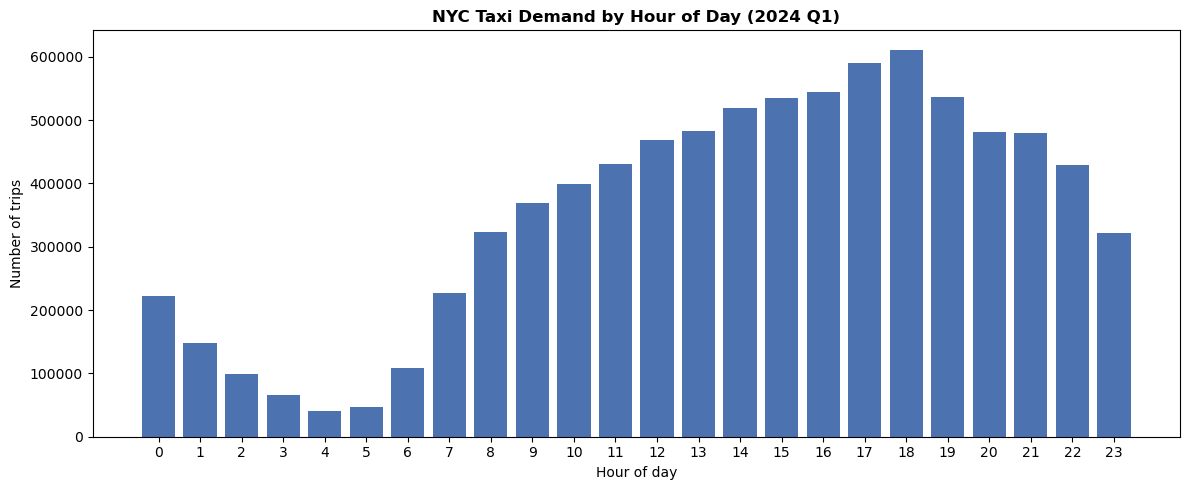

In [10]:
import matplotlib.pyplot as plt

# Convert the small aggregated result to pandas for plotting
hourly_pd = hourly.toPandas()

plt.figure(figsize=(12, 5))
plt.bar(hourly_pd["hour_of_day"], hourly_pd["num_trips"], color="#4C72B0")
plt.title("NYC Taxi Demand by Hour of Day (2024 Q1)", fontweight="bold")
plt.xlabel("Hour of day")
plt.ylabel("Number of trips")
plt.xticks(range(24))
plt.tight_layout()
plt.show()


In [11]:
# Trips and average fare by day of the week
daily = spark.sql("""
    SELECT DATE_FORMAT(tpep_pickup_datetime, 'EEEE') AS day_of_week,
           DAYOFWEEK(tpep_pickup_datetime)           AS dow_num,
           COUNT(*)                                  AS num_trips,
           ROUND(AVG(total_amount), 2)               AS avg_fare
    FROM trips
    GROUP BY DATE_FORMAT(tpep_pickup_datetime, 'EEEE'),
             DAYOFWEEK(tpep_pickup_datetime)
    ORDER BY dow_num
""")

daily.show()

+-----------+-------+---------+--------+
|day_of_week|dow_num|num_trips|avg_fare|
+-----------+-------+---------+--------+
|     Sunday|      1|  1054272|   28.26|
|     Monday|      2|  1033629|   29.13|
|    Tuesday|      3|  1171816|   27.79|
|  Wednesday|      4|  1281874|   27.82|
|   Thursday|      5|  1367843|    28.2|
|     Friday|      6|  1282568|   27.74|
|   Saturday|      7|  1287481|   25.52|
+-----------+-------+---------+--------+



### Insight 2: Weekly Demand Pattern

Breaking demand down by day of the week complements the hourly view and reveals a
clear weekly rhythm:

- **Thursday is the busiest day** (**1.37M** trips), followed closely by Saturday and
  Friday (~1.28M each). Demand builds steadily from Monday to its Thursday peak and
  stays high through the weekend.
- **Sunday (1.05M) and Monday (1.03M) are the quietest days** - about **25% fewer**
  trips than Thursday.
- **Fare value shifts across the week.** Monday has the **highest average fare**
  (**\$29.13**) while Saturday has the **lowest** (**\$25.52**). Weekday trips - commute,
  business and airport travel - tend to be longer and higher-value, whereas Saturday's
  leisure trips are shorter and cheaper.

**Business implications:**
- **Staffing & fleet** - scale up capacity Thursday-Saturday and scale down Sunday-Monday.
- **Weekend pricing** - Saturdays bring high volume but low value; promotions or bundled
  fares could lift per-trip revenue.
- **Business-travel segment** - Monday's high fare with low volume points to
  business/airport demand, a targetable high-value segment.

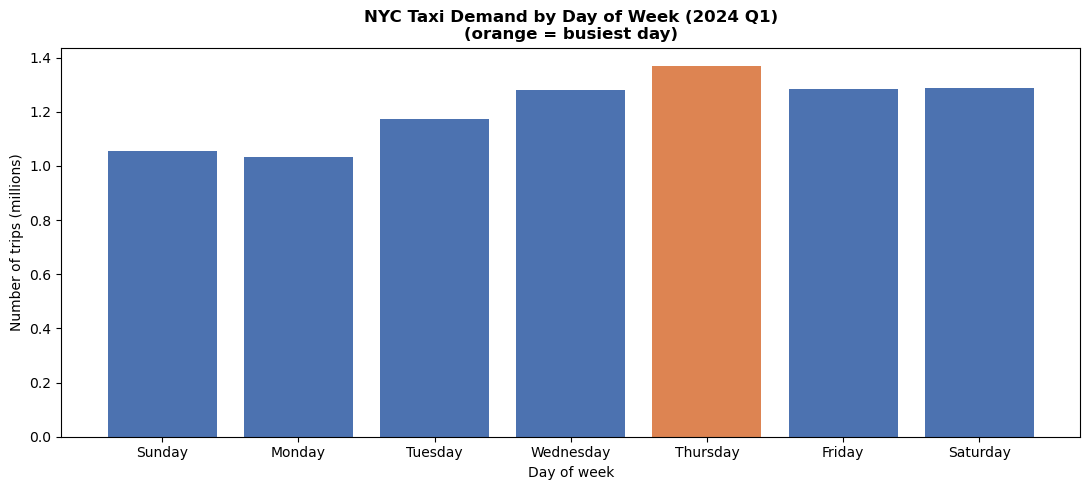

In [12]:
# Convert to pandas for plotting (already ordered Sunday -> Saturday)
daily_pd = daily.toPandas()
daily_pd["trips_millions"] = daily_pd["num_trips"] / 1_000_000

# Highlight the busiest day (Thursday) in orange
peak = daily_pd["num_trips"].max()
colors = ["#DD8452" if n == peak else "#4C72B0" for n in daily_pd["num_trips"]]

plt.figure(figsize=(11, 5))
plt.bar(daily_pd["day_of_week"], daily_pd["trips_millions"], color=colors)
plt.title("NYC Taxi Demand by Day of Week (2024 Q1)\n(orange = busiest day)",
          fontweight="bold")
plt.xlabel("Day of week")
plt.ylabel("Number of trips (millions)")
plt.tight_layout()
plt.show()

In [13]:
# Load the taxi zone lookup table (small reference CSV)
zones = spark.read.csv(
    "data/raw/taxi_zone_lookup.csv",
    header=True,
    inferSchema=True
)
zones.show(5)
print(f"Total zones: {zones.count()}")


+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows

Total zones: 265


In [14]:
# Join trips with zone names and aggregate revenue by pickup zone
zone_revenue = (
    df_clean.join(zones, df_clean.PULocationID == zones.LocationID, "left")
    .groupBy("Zone", "Borough")
    .agg(
        F.count("*").alias("num_trips"),
        F.round(F.sum("total_amount"), 2).alias("total_revenue"),
        F.round(F.avg("total_amount"), 2).alias("avg_fare"),
    )
    .orderBy(F.desc("total_revenue"))
)

# Top 10 pickup zones by total revenue
zone_revenue.show(10, truncate=False)

+----------------------------+---------+---------+-------------+--------+
|Zone                        |Borough  |num_trips|total_revenue|avg_fare|
+----------------------------+---------+---------+-------------+--------+
|JFK Airport                 |Queens   |404520   |3.311755864E7|81.87   |
|LaGuardia Airport           |Queens   |274807   |1.842890602E7|67.06   |
|Midtown Center              |Manhattan|418361   |1.022155434E7|24.43   |
|Times Sq/Theatre District   |Manhattan|301701   |8278287.48   |27.44   |
|Upper East Side South       |Manhattan|410576   |8253022.7    |20.1    |
|Upper East Side North       |Manhattan|382587   |7858995.75   |20.54   |
|Midtown East                |Manhattan|313485   |7458547.77   |23.79   |
|Penn Station/Madison Sq West|Manhattan|300367   |7396863.09   |24.63   |
|Lincoln Square East         |Manhattan|289787   |6223062.21   |21.47   |
|Midtown North               |Manhattan|254839   |6127996.64   |24.05   |
+----------------------------+--------

### Insight 3: Revenue by Pickup Zone

Joining trips with the zone lookup table and aggregating revenue by pickup zone
reveals **two very different revenue engines**:

- **Airports dominate total revenue.** JFK (**\$33.1M**) and LaGuardia (**\$18.4M**)
  are the top two revenue-generating pickup zones — together **~\$51.5M**, far ahead
  of any Manhattan zone — despite having fewer trips than several Manhattan areas.
- **Airport trips are high-value.** JFK's average fare (**\$81.87**) and LaGuardia's
  (**\$67.06**) are roughly **3-4x** the typical Manhattan zone (~\$20-25), driven by
  long distances plus airport fees.
- **Manhattan wins on volume, not value.** Midtown Center has the **most trips**
  (418,361) but an average fare of only **\$24.43**. Manhattan fills positions 3-10
  with high frequency but modest per-trip revenue.

**Business implications:**
- **Airport strategy** - prioritize coverage and a dedicated airport fleet; these are
  the highest revenue-per-trip opportunities.
- **Manhattan strategy** - compete on **volume and efficiency**: fast turnaround and
  short-trip throughput rather than high per-trip value.
- **Driver economics** - a single airport run is worth ~3x a Midtown run; this should
  inform incentives and how drivers position themselves throughout the day.

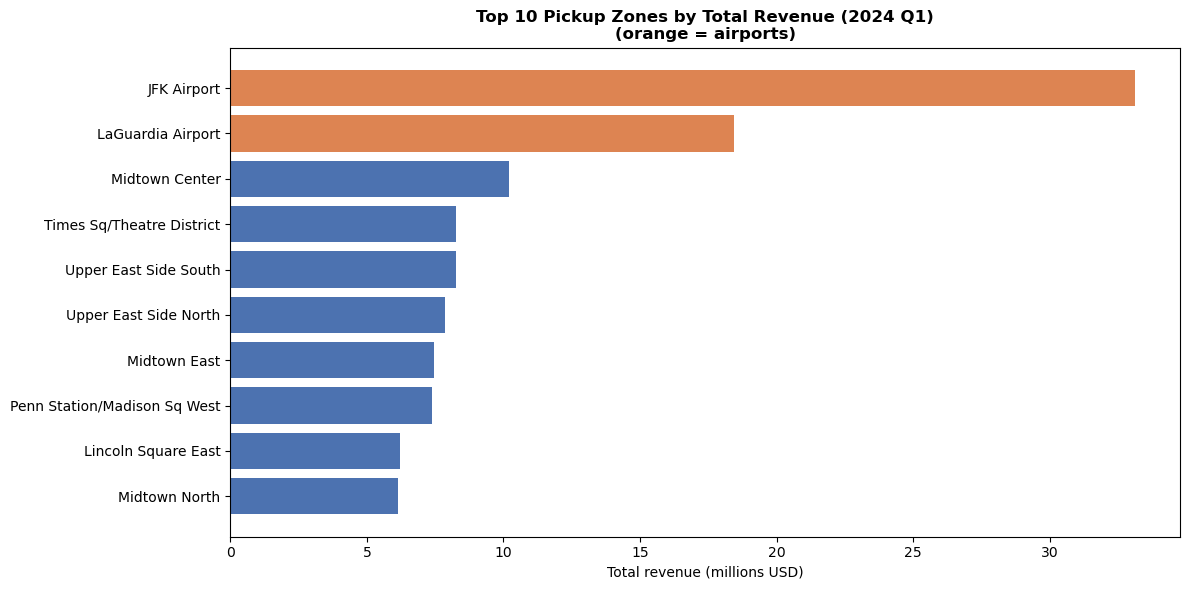

In [15]:
# Convert the top 10 zones to pandas for plotting (revenue in millions)
top_zones_pd = zone_revenue.limit(10).toPandas()
top_zones_pd["revenue_millions"] = top_zones_pd["total_revenue"] / 1_000_000

# Color airports differently to highlight the key insight
colors = ["#DD8452" if b == "Queens" else "#4C72B0" for b in top_zones_pd["Borough"]]

plt.figure(figsize=(12, 6))
plt.barh(top_zones_pd["Zone"], top_zones_pd["revenue_millions"], color=colors)
plt.gca().invert_yaxis()  # highest revenue on top
plt.title("Top 10 Pickup Zones by Total Revenue (2024 Q1)\n(orange = airports)",
          fontweight="bold")
plt.xlabel("Total revenue (millions USD)")
plt.tight_layout()
plt.show()

In [16]:
# Payment method breakdown: volume, average tip and average total
payment = spark.sql("""
    SELECT payment_type,
           CASE payment_type
                WHEN 1 THEN 'Credit card'
                WHEN 2 THEN 'Cash'
                WHEN 3 THEN 'No charge'
                WHEN 4 THEN 'Dispute'
                ELSE 'Other'
           END                          AS payment_method,
           COUNT(*)                     AS num_trips,
           ROUND(AVG(tip_amount), 2)    AS avg_tip,
           ROUND(AVG(total_amount), 2)  AS avg_total
    FROM trips
    GROUP BY payment_type
    ORDER BY num_trips DESC
""")

payment.show()

+------------+--------------+---------+-------+---------+
|payment_type|payment_method|num_trips|avg_tip|avg_total|
+------------+--------------+---------+-------+---------+
|           1|   Credit card|  7112984|    4.2|    28.44|
|           2|          Cash|  1260787|    0.0|    23.95|
|           4|       Dispute|    74148|   0.02|    25.69|
|           3|     No charge|    31564|   0.01|    23.04|
+------------+--------------+---------+-------+---------+



### Insight 4: Payment Methods & the Tipping Data Trap

Breaking trips down by payment method surfaces both a clear behavioral pattern and an
important **data-quality trap**:

- **Card dominates.** Credit card accounts for **7.1M** trips (~84%) vs **1.26M** for
  cash (~15%). Digital payment is by far the norm.
- **The tipping trap.** Card trips average a **\$4.20** tip, while cash trips average
  **\$0.00**. Taken at face value, this suggests "cash customers never tip" — but that
  conclusion would be **wrong**.

**Why the \$0 cash tip is a data artifact, not reality**

It is not credible that 1.26M cash trips had exactly zero tips. The real explanation
is **how the data is captured**: the meter only records tips paid **electronically**
(by card). Cash tips are handed directly to the driver and never enter the system, so
they show up as \$0.

**The lesson (and the business implication):**
- **Question the data before trusting it.** A naive analysis would under-report total
  tipping and unfairly conclude cash riders don't tip. Recognizing the collection bias
  prevents a false, potentially costly conclusion.
- **For any tipping or driver-earnings analysis, restrict to card trips** (where tips are
  actually recorded), and treat cash tips as unmeasured rather than zero.

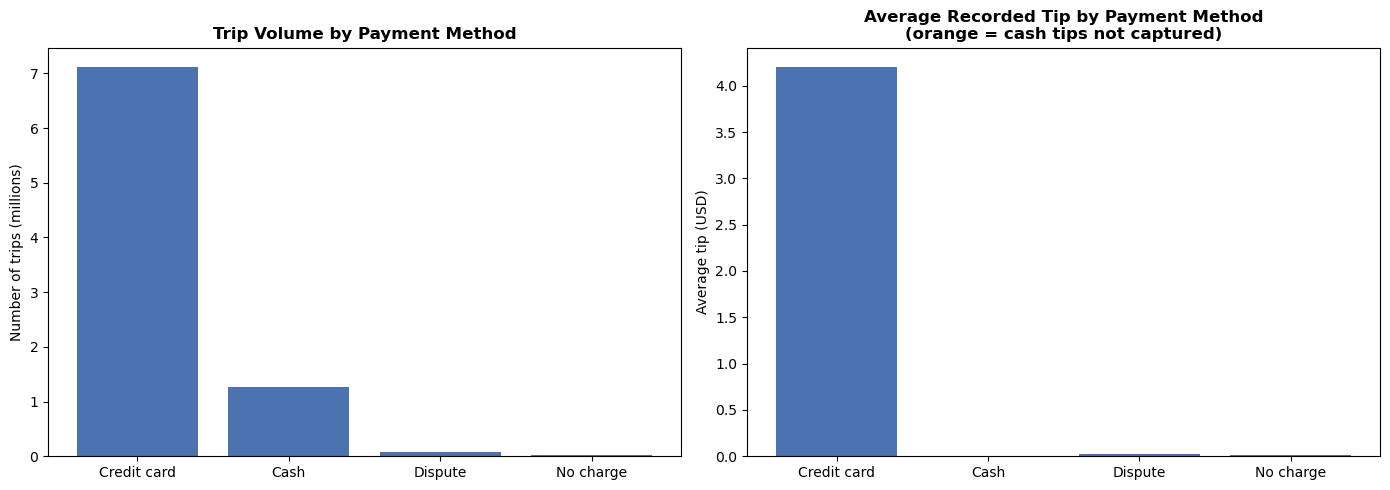

In [17]:
# Average recorded tip by payment method (highlights the cash data gap)
payment_pd = payment.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: trip volume by payment method
axes[0].bar(payment_pd["payment_method"], payment_pd["num_trips"] / 1_000_000,
            color="#4C72B0")
axes[0].set_title("Trip Volume by Payment Method", fontweight="bold")
axes[0].set_ylabel("Number of trips (millions)")

# Right: average recorded tip — cash shows ~$0 due to a data-collection gap
tip_colors = ["#DD8452" if m == "Cash" else "#4C72B0" for m in payment_pd["payment_method"]]
axes[1].bar(payment_pd["payment_method"], payment_pd["avg_tip"], color=tip_colors)
axes[1].set_title("Average Recorded Tip by Payment Method\n(orange = cash tips not captured)",
                  fontweight="bold")
axes[1].set_ylabel("Average tip (USD)")

plt.tight_layout()
plt.show()

## Conclusions & Key Takeaways

This project processed **~9.5M NYC yellow taxi trips (2024 Q1)** with PySpark to
demonstrate a big-data workflow end to end: distributed loading, a data-quality
investigation, cleaning, SQL analytics, and business-focused insights.

**Key findings**

1. **Demand is highly time-dependent** — trips peak from **5-7 PM** (evening commute)
   and bottom out around **4 AM**, with a strong late-night signal from NYC nightlife.
2. **The week has a clear rhythm** — **Thursday** is the busiest day and **Sunday/Monday**
   the quietest; weekend fares run lower (shorter leisure trips).
3. **Airports are the revenue engine** — JFK and LaGuardia generate the most revenue
   (~\$51.5M combined) with fares **3-4x** higher than Manhattan, while Manhattan wins
   on sheer volume.
4. **Question the data** — the **\$0 average cash tip** is a data-collection artifact
   (only card tips are recorded), not real behavior. A naive read would draw a false
   conclusion; tipping analysis should be restricted to card trips.

**Technical highlights**

- Processed ~9.5M rows with **PySpark** (Spark SQL + DataFrame API) on a single machine.
- **Investigated a data-quality gap** (how NULLs behave in filters) instead of ignoring it.
- **Cached** reused data to speed up repeated queries.
- Translated **every result into a business implication** — the analysis is decision-ready,
  not just numbers.

In [18]:
# Release the cached data and shut down the Spark session
df_clean.unpersist()
spark.stop()
print("Spark session stopped.")

Spark session stopped.
